In [1]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import hdf5plugin
import numpy as np
import anndata as ad
from scipy.sparse import csr_matrix
import scanpy as sc
import matplotlib.pyplot as plt
import rapids_singlecell as rsc 

# Single seed propagated to every stochastic op below. With USE_RAPIDS=False
# the entire downstream pipeline is bitwise reproducible. On the rapids path
# the seed is still passed but cuML kernels aren't bitwise deterministic.
SEED = 137
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)

In [2]:
# Global backend switch for stochastic GPU vs deterministic CPU paths.
#   True  → cuML/rapids (faster, but GPU kernels aren't bitwise reproducible)
#   False → scanpy/CPU  (slower, deterministic given a fixed seed)
# Affects normalization, HVG, scaling, PCA, neighbors, Leiden, and UMAP downstream.
USE_RAPIDS = True
norm_fn   = rsc.pp.normalize_total       if USE_RAPIDS else sc.pp.normalize_total
log1p_fn  = rsc.pp.log1p                 if USE_RAPIDS else sc.pp.log1p
hvg_fn    = rsc.pp.highly_variable_genes if USE_RAPIDS else sc.pp.highly_variable_genes
scale_fn  = rsc.pp.scale                 if USE_RAPIDS else sc.pp.scale
pca_fn    = rsc.pp.pca                   if USE_RAPIDS else sc.pp.pca
nbrs_fn   = rsc.pp.neighbors             if USE_RAPIDS else sc.pp.neighbors
leiden_fn = rsc.tl.leiden                if USE_RAPIDS else sc.tl.leiden
umap_fn   = rsc.tl.umap                  if USE_RAPIDS else sc.tl.umap

In [3]:
# initialize benchmarking dataset
DATA_PATH = "../data/cellPLM/data/gse155468.h5ad"
data      = ad.read_h5ad(DATA_PATH)
data.obs_names_make_unique()

In [4]:
# Standard preprocessing → PCA baseline. Routed through the global backend
# (rapids GPU vs scanpy CPU) for every step.
# Pipeline: depth-normalize → log1p → HVG selection → z-score → PCA.
# Operates on a copy so `data.X` retains raw counts for other methods.
adata_pp = data.copy()

# cuPy sparse only supports float types; data.X is int64 raw counts → cast.
adata_pp.X = adata_pp.X.astype(np.float32)

# Move to GPU for the rapids path; no-op on the scanpy path.
if USE_RAPIDS:
    rsc.get.anndata_to_GPU(adata_pp)

# Library-size normalize each cell to 10k counts, then log-transform.
norm_fn(adata_pp, target_sum=1e4)
log1p_fn(adata_pp)

# Restrict to top 4500 highly variable genes to focus PCA on biological signal.
hvg_fn(adata_pp, n_top_genes=4500)
adata_pp = adata_pp[:, adata_pp.var.highly_variable].copy()

# Z-score per gene (clip outliers at ±10), then PCA (seeded).
scale_fn(adata_pp, max_value=10)
pca_fn(adata_pp, n_comps=512, random_state=SEED)

# Move back to CPU so obsm[X_pca] is a numpy array we can stash on `data`.
if USE_RAPIDS:
    rsc.get.anndata_to_CPU(adata_pp)

data.obsm["pca_scanpy_emb"] = adata_pp.obsm["X_pca"]

In [5]:
# Load the cellPLM embedding and align it to the original AnnData by cell ID.
# Embedding file layout (written by cellPLM-embedding-wrapper/generate_embedding.ipynb):
#   X         : (n_cells, d) float32         -- the latent vectors
#   obs_names : original adata.obs_names      -- canonical cell IDs
#   var_names : ['dim_0', 'dim_1', ...]       -- arbitrary dim labels

cellPLM_EMB_PATH  = "cellPLM-embedding-wrapper/gse155468_embedding.h5ad"

emb_adata = ad.read_h5ad(cellPLM_EMB_PATH)

# Re-align by cell ID rather than trusting positional order (cellPLM preserves
# input order, but other adapters may not).
common = data.obs_names.intersection(emb_adata.obs_names)
assert len(common) == data.n_obs == emb_adata.n_obs, (
    f"cell-ID mismatch: data={data.n_obs}, emb={emb_adata.n_obs}, common={len(common)}"
)
emb_adata = emb_adata[data.obs_names].copy()
data.obsm["cellPLM_emb"] = emb_adata.X 

print(f"data:        {data.shape}, obsm keys: {list(data.obsm.keys())}")
print(f"obs cols: {data.obs.columns.tolist()}")
print(f"cellPLM_emb: shape={data.obsm['cellPLM_emb'].shape}, "
      f"dtype={data.obsm['cellPLM_emb'].dtype}")

data:        (48082, 12382), obsm keys: ['pca_scanpy_emb', 'cellPLM_emb']
obs cols: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'stim', 'integrated_snn_res.0.6', 'seurat_clusters', 'celltype', 'celltype2']
cellPLM_emb: shape=(48082, 512), dtype=float32


In [6]:
# Load the scGPT embedding and align it to the original AnnData by cell ID.
# Embedding file layout (written by scGPT-embedding-wrapper/generate_embedding.ipynb):
#   X         : (n_cells, d) float32         -- the latent vectors
#   obs_names : original adata.obs_names      -- canonical cell IDs
#   var_names : ['dim_0', 'dim_1', ...]       -- arbitrary dim labels

scGPT_EMB_PATH = "scGPT-embedding-wrapper/gse155468_embedding.h5ad"

emb_adata = ad.read_h5ad(scGPT_EMB_PATH)

# Re-align by cell ID rather than trusting positional order.
common = data.obs_names.intersection(emb_adata.obs_names)
assert len(common) == data.n_obs == emb_adata.n_obs, (
    f"cell-ID mismatch: data={data.n_obs}, emb={emb_adata.n_obs}, common={len(common)}"
)
emb_adata = emb_adata[data.obs_names].copy()
data.obsm["scGPT_emb"] = emb_adata.X

print(f"data:      {data.shape}, obsm keys: {list(data.obsm.keys())}")
print(f"scGPT_emb: shape={data.obsm['scGPT_emb'].shape}, "
      f"dtype={data.obsm['scGPT_emb'].dtype}")

data:      (48082, 12382), obsm keys: ['pca_scanpy_emb', 'cellPLM_emb', 'scGPT_emb']
scGPT_emb: shape=(48082, 512), dtype=float32


In [7]:
# Load the Geneformer embedding and align it to the original AnnData by cell ID.
# Embedding file layout (written by Geneformer-embedding-wrapper/generate_embedding.ipynb):
#   X         : (n_cells, d) float32         -- the latent vectors (V2-104M -> d=768)
#   obs_names : original adata.obs_names      -- canonical cell IDs
#   var_names : ['dim_0', 'dim_1', ...]       -- arbitrary dim labels

geneformer_EMB_PATH = "Geneformer-embedding-wrapper/gse155468_embedding.h5ad"

emb_adata = ad.read_h5ad(geneformer_EMB_PATH)

# Re-align by cell ID rather than trusting positional order.
common = data.obs_names.intersection(emb_adata.obs_names)
assert len(common) == data.n_obs == emb_adata.n_obs, (
    f"cell-ID mismatch: data={data.n_obs}, emb={emb_adata.n_obs}, common={len(common)}"
)
emb_adata = emb_adata[data.obs_names].copy()
data.obsm["geneformer_emb"] = emb_adata.X

print(f"data:           {data.shape}, obsm keys: {list(data.obsm.keys())}")
print(f"geneformer_emb: shape={data.obsm['geneformer_emb'].shape}, "
      f"dtype={data.obsm['geneformer_emb'].dtype}")

data:           (48082, 12382), obsm keys: ['pca_scanpy_emb', 'cellPLM_emb', 'scGPT_emb', 'geneformer_emb']
geneformer_emb: shape=(48082, 768), dtype=float32


In [8]:
# Load the scFoundation embedding and align it to the original AnnData by cell ID.
# Embedding file layout (written by scFoundation-embedding-wrapper/generate_embedding.ipynb):
#   X         : (n_cells, d) float32         -- the latent vectors
#                                                (POOL_TYPE='all' on the 100M model -> d=3072)
#   obs_names : original adata.obs_names      -- canonical cell IDs
#   var_names : ['dim_0', 'dim_1', ...]       -- arbitrary dim labels

scfoundation_EMB_PATH = "scFoundation-embedding-wrapper/gse155468_embedding.h5ad"

emb_adata = ad.read_h5ad(scfoundation_EMB_PATH)

# Re-align by cell ID rather than trusting positional order.
common = data.obs_names.intersection(emb_adata.obs_names)
assert len(common) == data.n_obs == emb_adata.n_obs, (
    f"cell-ID mismatch: data={data.n_obs}, emb={emb_adata.n_obs}, common={len(common)}"
)
emb_adata = emb_adata[data.obs_names].copy()
data.obsm["scfoundation_emb"] = emb_adata.X

print(f"data:             {data.shape}, obsm keys: {list(data.obsm.keys())}")
print(f"scfoundation_emb: shape={data.obsm['scfoundation_emb'].shape}, "
      f"dtype={data.obsm['scfoundation_emb'].dtype}")

data:             (48082, 12382), obsm keys: ['pca_scanpy_emb', 'cellPLM_emb', 'scGPT_emb', 'geneformer_emb', 'scfoundation_emb']
scfoundation_emb: shape=(48082, 3072), dtype=float32


In [9]:
# Load the scVI embedding and align it to the original AnnData by cell ID.
# Embedding file layout (written by scVI-embedding-wrapper/generate_embedding.ipynb):
#   X         : (n_cells, d) float32         -- the latent vectors (default N_LATENT=30)
#   obs_names : original adata.obs_names      -- canonical cell IDs
#   var_names : ['dim_0', 'dim_1', ...]       -- arbitrary dim labels
#
# Note: scVI is the only model here that's TRAINED per-dataset (not pretrained),
# so its embedding is specific to gse155468 — re-running the wrapper on a new
# dataset gives a fresh model and a different latent space.

scvi_EMB_PATH = "scVI-embedding-wrapper/gse155468_embedding.h5ad"

emb_adata = ad.read_h5ad(scvi_EMB_PATH)

# Re-align by cell ID rather than trusting positional order.
common = data.obs_names.intersection(emb_adata.obs_names)
assert len(common) == data.n_obs == emb_adata.n_obs, (
    f"cell-ID mismatch: data={data.n_obs}, emb={emb_adata.n_obs}, common={len(common)}"
)
emb_adata = emb_adata[data.obs_names].copy()
data.obsm["scvi_emb"] = emb_adata.X

print(f"data:     {data.shape}, obsm keys: {list(data.obsm.keys())}")
print(f"scvi_emb: shape={data.obsm['scvi_emb'].shape}, "
      f"dtype={data.obsm['scvi_emb'].dtype}")

data:     (48082, 12382), obsm keys: ['pca_scanpy_emb', 'cellPLM_emb', 'scGPT_emb', 'geneformer_emb', 'scfoundation_emb', 'scvi_emb']
scvi_emb: shape=(48082, 30), dtype=float32


Embeddings to evaluate: ['pca_scanpy_emb', 'cellPLM_emb', 'scGPT_emb', 'geneformer_emb', 'scfoundation_emb', 'scvi_emb']  (backend: rapids)
pca_scanpy_emb   ARI=0.8422 (res=0.2)  NMI=0.8288 (res=0.2)
cellPLM_emb      ARI=0.8315 (res=0.1)  NMI=0.8102 (res=0.2)
scGPT_emb        ARI=0.8685 (res=0.1)  NMI=0.8487 (res=0.1)
geneformer_emb   ARI=0.6432 (res=0.1)  NMI=0.7610 (res=0.3)
scfoundation_emb  ARI=0.6153 (res=0.1)  NMI=0.7691 (res=0.1)
scvi_emb         ARI=0.8739 (res=0.3)  NMI=0.8449 (res=0.2)


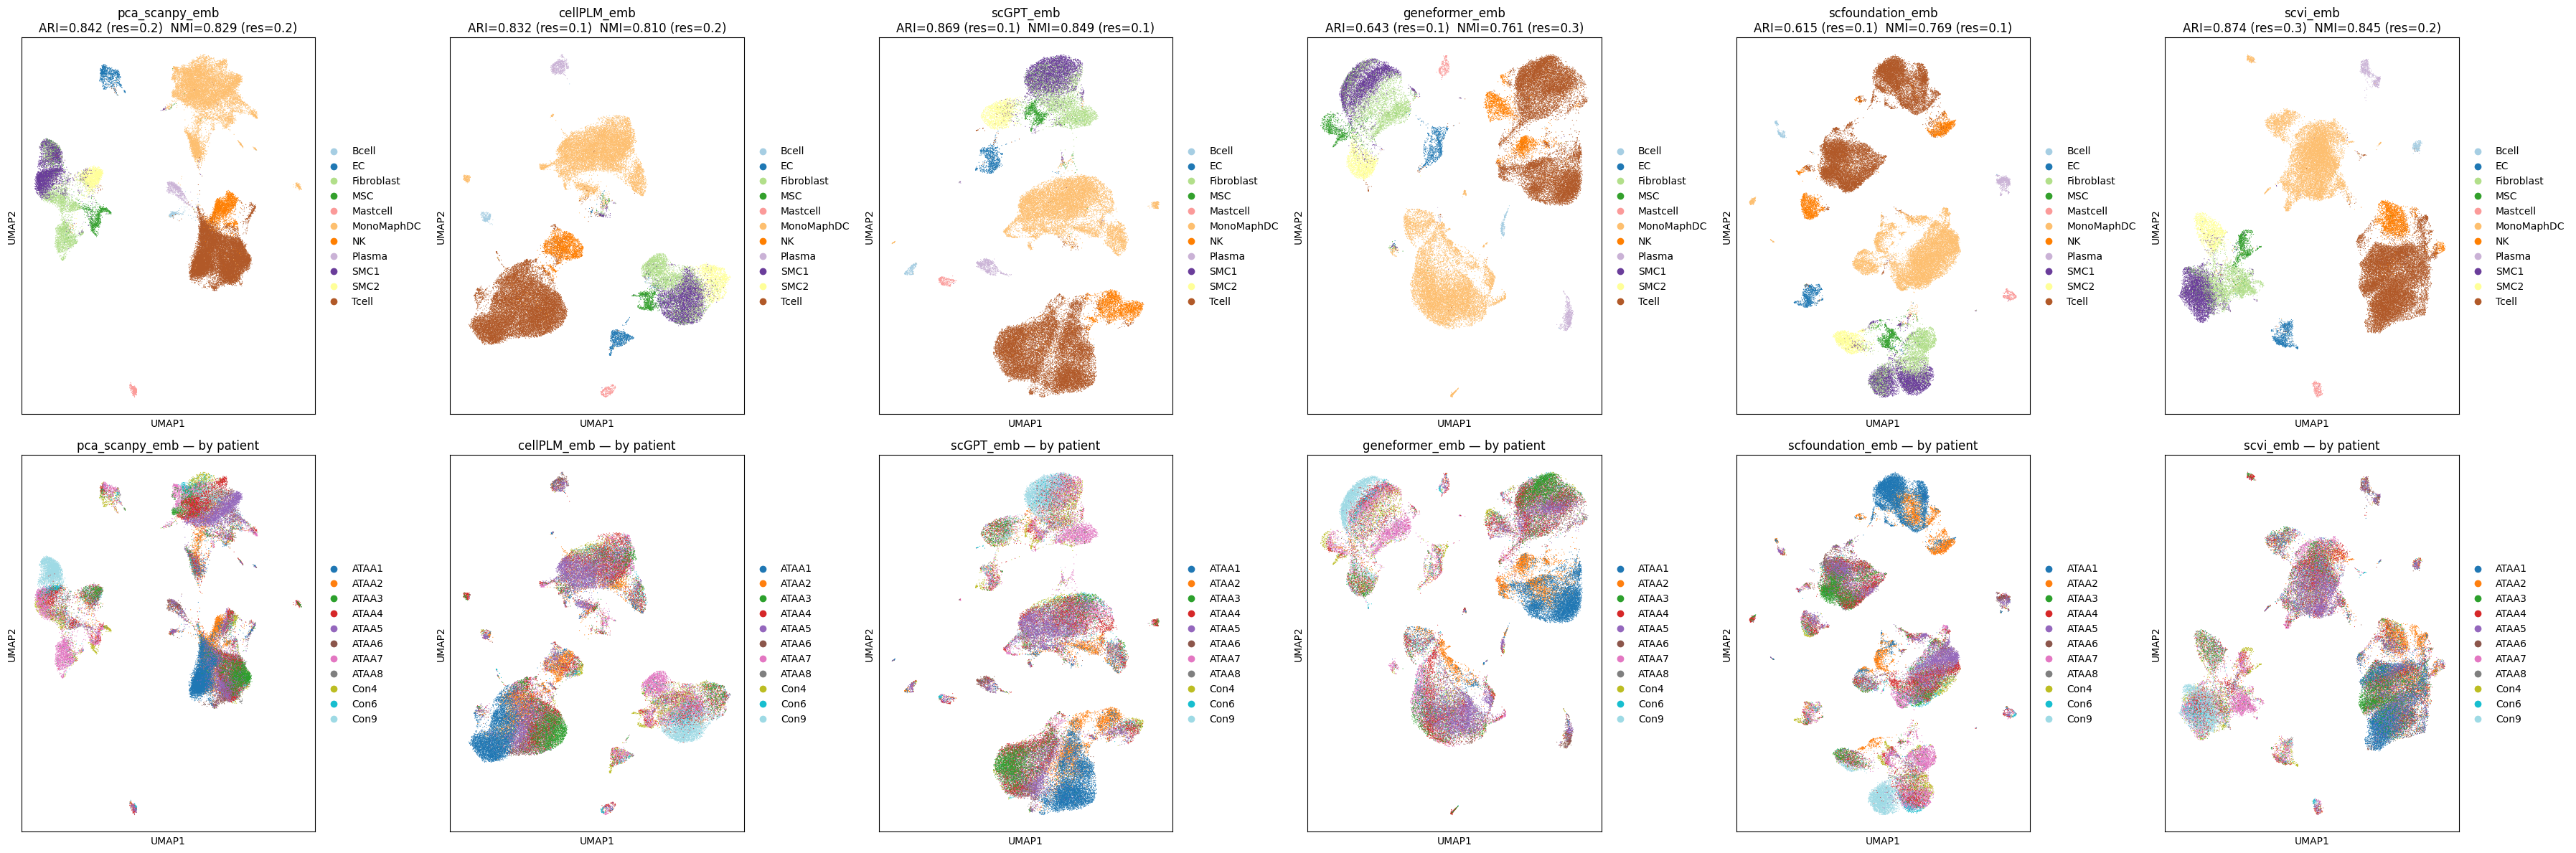

In [10]:
# Score every embedding in obsm by kNN-Leiden against ground-truth `celltype`,
# compute one UMAP per embedding, and render two coloring views (celltype + donor)
# of the same layout. Backend (rapids vs scanpy) follows the global USE_RAPIDS switch.
#
# Mirrors CellPLM's score(): build kNN graph, sweep Leiden resolutions
# (0.1..1.4), keep best ARI and best NMI independently. The neighbors graph
# computed for scoring is reused for the UMAP — no recomputation.
# All stochastic ops are seeded with SEED so the scanpy path is reproducible.
from sklearn.metrics.cluster import adjusted_rand_score, normalized_mutual_info_score


def score_embedding(adata, emb_key, label_key,
                    resolutions=None, n_neighbors=15):
    """Cluster cells by kNN-Leiden on `obsm[emb_key]` and grade against `obs[label_key]`.

    Returns dict with the best ARI and best NMI over the resolution sweep
    (each metric maximized independently — they may come from different resolutions).
    Side effect: leaves neighbors graph cached on `adata` for downstream UMAP.
    """
    if resolutions is None:
        resolutions = [r / 10 for r in range(1, 15)]   # 0.1 .. 1.4 — same as CellPLM

    nbrs_fn(adata, use_rep=emb_key, n_neighbors=n_neighbors, random_state=SEED)
    truth = adata.obs[label_key].to_numpy()
    best_ari = best_nmi = -1.0
    best_ari_res = best_nmi_res = None
    for res in resolutions:
        leiden_fn(adata, resolution=res, key_added='leiden', random_state=SEED)
        pred = adata.obs['leiden'].to_numpy()
        ari = adjusted_rand_score(pred, truth)
        nmi = normalized_mutual_info_score(pred, truth)
        if ari > best_ari:
            best_ari, best_ari_res = ari, res
        if nmi > best_nmi:
            best_nmi, best_nmi_res = nmi, res
    return {'ari': best_ari, 'nmi': best_nmi,
            'best_ari_res': best_ari_res, 'best_nmi_res': best_nmi_res}


emb_keys = [k for k in data.obsm.keys() if k.endswith('_emb')]
print(f"Embeddings to evaluate: {emb_keys}  (backend: {'rapids' if USE_RAPIDS else 'scanpy'})")

# 2 rows × N embeddings: top = celltype, bottom = donor — same UMAP, different color.
fig, axes = plt.subplots(2, len(emb_keys),
                         figsize=(6 * len(emb_keys), 12),
                         squeeze=False)

results = {}
for col, key in enumerate(emb_keys):
    # score_embedding builds the kNN graph (cached on `data`); UMAP reuses it.
    r = score_embedding(data, emb_key=key, label_key='celltype')
    results[key] = r
    print(f"{key:15s}  ARI={r['ari']:.4f} (res={r['best_ari_res']})  "
          f"NMI={r['nmi']:.4f} (res={r['best_nmi_res']})")

    umap_fn(data, random_state=SEED)

    title = (f"{key}\nARI={r['ari']:.3f} (res={r['best_ari_res']})  "
             f"NMI={r['nmi']:.3f} (res={r['best_nmi_res']})")
    sc.pl.umap(data, color='celltype', palette='Paired',
               ax=axes[0, col], show=False, title=title)
    sc.pl.umap(data, color='orig.ident', palette='tab20',
               ax=axes[1, col], show=False, title=f"{key} — by patient")

plt.tight_layout()
plt.show()